
## MALL Cleaning (5-Minute Base)



**Purpose:** This notebook constructs the 5-minute MALL feature set by using the new 5-minute intraday MHAR dataset as the starting point and then appending the same macro-financial predictors used in the original MALL notebook. The goal is to preserve the original feature logic while replacing the realized-variance base with a lower-noise 5-minute construction.


In [4]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

# Load 5-minute MHAR dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MHAR_5min_intraday.csv"
MHAR = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MHAR.shape}")
print(f"Index type: {type(MHAR.index)}")
print(f"Index dtype: {MHAR.index.dtype}")
print(f"Date range: {MHAR.index[0].strftime('%Y-%m-%d')} to {MHAR.index[-1].strftime('%Y-%m-%d')}")
print(f"NaN values: {MHAR.isna().sum().sum()}")
print("\nFirst few rows:")
MHAR.head()


Shape: (5674, 12)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index dtype: datetime64[ns]
Date range: 1998-03-30 to 2020-08-07
NaN values: 0

First few rows:


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,RM_neg,RQ
Date,,,,,,,,,,,,
1998-03-30,0.000071,0.000060,0.000064,-9.550019,-9.727785,-9.653726,0.000032,0.000039,-0.003233,0.0,0.0,7.017334e-09
1998-03-31,0.000053,0.000058,0.000064,-9.844566,-9.746576,-9.649957,0.000026,0.000027,0.000000,0.0,0.0,4.848406e-09
1998-04-01,0.000065,0.000063,0.000064,-9.638335,-9.676560,-9.652131,0.000043,0.000022,0.000000,0.0,0.0,4.904402e-09
1998-04-02,0.000045,0.000059,0.000064,-10.009022,-9.730652,-9.656873,0.000030,0.000015,0.000000,0.0,0.0,3.868715e-09
1998-04-03,0.000077,0.000062,0.000065,-9.473854,-9.684375,-9.637785,0.000050,0.000027,0.000000,0.0,0.0,8.732961e-09



### 1. Adding Variables to Create the 5-Minute MALL Dataset
We begin from the 5-minute intraday MHAR feature set and then merge each external variable using a left join so that the EURO STOXX 50 trading calendar remains the reference calendar throughout the construction process.


In [6]:

# Use the 5-minute MHAR feature set as the base dataframe
MALL = MHAR.copy()


#### 1.1 VSTOXX Index

In [10]:

# Load VSTOXX data
vstoxx_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/VSTOXX.csv"
VSTOXX = pd.read_csv(vstoxx_path)

# Drop Symbol column as it is constant and uninformative
VSTOXX = VSTOXX.drop(columns=["Symbol"])

# Convert Date to DatetimeIndex
VSTOXX["Date"] = pd.to_datetime(VSTOXX["Date"])
VSTOXX = VSTOXX.set_index("Date")

# Rename column to uppercase for consistency
VSTOXX = VSTOXX.rename(columns={"vstoxx": "VSTOXX"})

# Merge with the 5-minute base dataset and forward fill non-trading gaps
MALL = MALL.join(VSTOXX, how="left")
MALL["VSTOXX"] = MALL["VSTOXX"].ffill()

# Log transform for log-based extensions
MALL["logVSTOXX"] = np.log(MALL["VSTOXX"])



#### 1.2 EPU Index
Economic policy uncertainty is included in both level and log form. We also retain the one-month lagged version to reflect slower-moving macro-financial uncertainty, in line with the original MALL construction.


In [13]:

# Load EPU data
epu_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/EPU.xlsx"
EPU = pd.read_excel(epu_path)

# Drop the last row which is a source citation
EPU = EPU.dropna(subset=["Month"])

# Keep only European News Index
EPU = EPU[["Year", "Month", "European_News_Index"]].copy()
EPU["Year"] = EPU["Year"].astype(int)
EPU["Month"] = EPU["Month"].astype(int)

# Construct month-start timestamps
EPU["Date"] = pd.to_datetime(
    EPU["Year"].astype(str) + "-" + EPU["Month"].astype(str) + "-01"
)
EPU = EPU.set_index("Date")
EPU = EPU.drop(columns=["Year", "Month"])
EPU = EPU.rename(columns={"European_News_Index": "EPU"})

# Merge and fill monthly values across trading days
MALL = MALL.join(EPU, how="left")
MALL["EPU"] = MALL["EPU"].ffill()
MALL["logEPU"] = np.log(MALL["EPU"])

# One-month lagged EPU aligned to month starts
MALL["EPU_1m_lag"] = (
    MALL["EPU"]
    .resample("MS")
    .first()
    .shift(1)
    .reindex(MALL.index, method="ffill")
)
MALL["logEPU_1m_lag"] = np.log(MALL["EPU_1m_lag"])



### 1.3 EUR/USD Exchange Rate
**Source:** ECB Data Portal.
We include the EUR/USD level and its daily log return to capture exchange-rate conditions relevant for European financial markets.


In [16]:

# Load EUR/USD exchange rate data from ECB
eurusd_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/ECB Data Portal long_20260311191107.xlsx"
EURUSD = pd.read_excel(eurusd_path, sheet_name="DATA(EXR)")

# Keep only DATE and OBS.VALUE columns
EURUSD = EURUSD[["DATE", "OBS.VALUE"]].copy()
EURUSD["DATE"] = pd.to_datetime(EURUSD["DATE"])
EURUSD = EURUSD.set_index("DATE")
EURUSD = EURUSD.rename(columns={"OBS.VALUE": "EURUSD"})

# Forward fill weekends and holidays before merging
EURUSD["EURUSD"] = EURUSD["EURUSD"].ffill()
MALL = MALL.join(EURUSD, how="left")
MALL["EURUSD_ret"] = np.log(MALL["EURUSD"] / MALL["EURUSD"].shift(1))



### 1.4 CISS
**Source:** ECB.
The Composite Indicator of Systemic Stress is included as a broad European stress proxy that complements implied-volatility and realized-volatility measures.


In [18]:

# Load CISS data
ciss_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/CISS.csv"
CISS = pd.read_csv(ciss_path)

# Rename the long ECB series label
CISS = CISS.rename(columns={
    "NEW CISS - Composite Indicator of Systemic Stress. (CISS.D.U2.Z0Z.4F.EC.SS_CIN.IDX)": "CISS"
})

CISS = CISS.drop(columns=["TIME PERIOD"])
CISS["DATE"] = pd.to_datetime(CISS["DATE"])
CISS = CISS.set_index("DATE")

MALL = MALL.join(CISS, how="left")



### 1.5 Europe Brent Crude Oil Spot Price
**Source:** U.S. Energy Information Administration (EIA).
Brent is added in both level and return form to capture commodity-market conditions that may spill over into European equity volatility.


In [20]:

# Load Brent crude oil price data, skipping metadata rows
brent_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/Europe_Brent_Spot_Price_FOB.csv"
BRENT = pd.read_csv(brent_path, skiprows=4)
BRENT.columns = ["Date", "BRENT"]
BRENT["Date"] = pd.to_datetime(BRENT["Date"])
BRENT = BRENT.set_index("Date")
BRENT = BRENT.sort_index()

MALL = MALL.join(BRENT, how="left")
MALL["BRENT"] = MALL["BRENT"].ffill()
MALL["BRENT_ret"] = np.log(MALL["BRENT"] / MALL["BRENT"].shift(1))



### 1.6 Global Spillovers: NIKKEI 225 and S&P 500
**Sources:** FRED for NIKKEI 225 and Wall Street Journal Markets for the S&P 500.
Following the original notebook, we include Asian and U.S. spillover proxies. Nikkei information is predetermined relative to the European trading day, while the S&P 500 variables are lagged by one day to avoid look-ahead bias.


#### 1.6.1 NIKKEI 225

In [23]:

# Load Nikkei 225 data
nikkei_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/NIKKEI225.csv"
NIKKEI = pd.read_csv(nikkei_path)

NIKKEI["observation_date"] = pd.to_datetime(NIKKEI["observation_date"])
NIKKEI = NIKKEI.set_index("observation_date")
NIKKEI.index.name = "Date"

# Forward fill Japanese holidays and compute return measures
NIKKEI["NIKKEI225"] = NIKKEI["NIKKEI225"].ffill()
NIKKEI["NIKKEI_ret"] = np.log(NIKKEI["NIKKEI225"] / NIKKEI["NIKKEI225"].shift(1))
NIKKEI["NIKKEI_sq"] = NIKKEI["NIKKEI_ret"].pow(2)

MALL = MALL.join(NIKKEI[["NIKKEI_ret", "NIKKEI_sq"]], how="left")


#### 1.6.2 S&P 500

In [25]:

# Load S&P 500 data
sp500_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/S&P500.csv"
SP500 = pd.read_csv(sp500_path)
SP500.columns = SP500.columns.str.strip()
SP500 = SP500[["Date", "Close"]].copy()
SP500["Date"] = pd.to_datetime(SP500["Date"], format="%m/%d/%y")
SP500 = SP500.set_index("Date")
SP500 = SP500.sort_index()

# Compute returns, then lag them by one day for European-market forecasting
SP500["SP500_ret"] = np.log(SP500["Close"] / SP500["Close"].shift(1))
SP500["SP500_ret_lag"] = SP500["SP500_ret"].shift(1)
SP500["SP500_sq_lag"] = SP500["SP500_ret_lag"].pow(2)

MALL = MALL.join(SP500[["SP500_ret_lag", "SP500_sq_lag"]], how="left")
MALL["SP500_ret_lag"] = MALL["SP500_ret_lag"].ffill()
MALL["SP500_sq_lag"] = MALL["SP500_sq_lag"].ffill()



### 1.7 Momentum Measures (M1W and M1M)
Momentum is constructed from daily close prices as 5-day and 22-day cumulative log-price changes, matching the original MALL specification.


In [27]:

# Load daily close prices
close_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/daily_close.csv"
close = pd.read_csv(close_path, index_col="Date", parse_dates=True)

close["log_close"] = np.log(close["Close"])
close["M1W"] = close["log_close"].diff(5)
close["M1M"] = close["log_close"].diff(22)

MALL = MALL.join(close[["M1W", "M1M"]], how="left")



### 1.8 Target Variables
As in the original MALL construction, we create next-day realized variance and its log transform so the resulting dataset can support both level and log specifications in later modeling notebooks.


In [29]:

# Construct next-day targets from the 5-minute realized variance base
MALL["RV_target"] = MALL["RVD"].shift(-1)
MALL["logRV_target"] = np.log(MALL["RV_target"])



### Final Status of the 5-Minute MALL Feature Set
We finish by dropping rows with missing values induced by lags, joins, and the target construction, and then verify the final sample.


In [31]:

# Final cleanup after all feature engineering steps
MALL = MALL.dropna()

print(f"Final MALL_5min shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].strftime('%Y-%m-%d')} to {MALL.index[-1].strftime('%Y-%m-%d')}")
print(f"NaN values: {MALL.isna().sum().sum()}")


Final MALL_5min shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


In [33]:

# Prepare transformed variables for a thesis-style summary table
MALL_display = pd.DataFrame({
    "RVD":           np.sqrt(MALL["RVD"] * 252) * 100,
    "RVW":           np.sqrt(MALL["RVW"] * 252) * 100,
    "RVM":           np.sqrt(MALL["RVM"] * 252) * 100,
    "logRVD":        MALL["logRVD"],
    "logRVW":        MALL["logRVW"],
    "logRVM":        MALL["logRVM"],
    "RVD_pos":       np.sqrt(MALL["RVD_pos"] * 252) * 100,
    "RVD_neg":       np.sqrt(MALL["RVD_neg"] * 252) * 100,
    "RD_neg":        MALL["RD_neg"] * 100,
    "RW_neg":        MALL["RW_neg"] * 100,
    "RM_neg":        MALL["RM_neg"] * 100,
    "RQ":            MALL["RQ"] * 1e6,
    "VSTOXX":        MALL["VSTOXX"],
    "logVSTOXX":     MALL["logVSTOXX"],
    "EPU":           MALL["EPU"],
    "logEPU":        MALL["logEPU"],
    "EPU_1m_lag":    MALL["EPU_1m_lag"],
    "logEPU_1m_lag": MALL["logEPU_1m_lag"],
    "EURUSD":        MALL["EURUSD"],
    "EURUSD_ret":    MALL["EURUSD_ret"] * 100,
    "CISS":          MALL["CISS"],
    "BRENT":         MALL["BRENT"],
    "BRENT_ret":     MALL["BRENT_ret"] * 100,
    "NIKKEI_ret":    MALL["NIKKEI_ret"] * 100,
    "NIKKEI_sq":     MALL["NIKKEI_sq"] * 1e4,
    "SP500_ret_lag": MALL["SP500_ret_lag"] * 100,
    "SP500_sq_lag":  MALL["SP500_sq_lag"] * 1e4,
    "M1W":           MALL["M1W"] * 100,
    "M1M":           MALL["M1M"] * 100,
})

summary = pd.DataFrame({
    "Obs.":       MALL_display.count(),
    "Mean":       MALL_display.mean(),
    "Median":     MALL_display.median(),
    "Std. Dev.":  MALL_display.std(),
    "Skewness":   MALL_display.skew(),
    "Exc. Kurt.": MALL_display.kurt(),
    "Min":        MALL_display.min(),
    "Max":        MALL_display.max(),
}).round(4)

styled_summary = (
    summary.style
    .set_caption(
        "Table: Summary Statistics of the 5-Minute MALL Feature Set — EURO STOXX 50 "
        f"({MALL.index[0].strftime('%Y-%m-%d')} to {MALL.index[-1].strftime('%Y-%m-%d')}). "
        "RVD, RVW, RVM, RVD$_{pos}$, and RVD$_{neg}$ are shown as annualized std (%). "
        "RD$_{neg}$, RW$_{neg}$, RM$_{neg}$, EURUSD$_{ret}$, BRENT$_{ret}$, NIKKEI$_{ret}$, "
        "SP500$_{ret}$, M1W, and M1M are shown as %. RQ is scaled by $10^{6}$, while "
        "NIKKEI$_{sq}$ and SP500$_{sq}$ are scaled by $10^{4}$."
    )
    .format(lambda x: f"{x:,.4f}")
    .format(lambda x: f"{int(x):,}", subset=pd.IndexSlice[:, "Obs."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "12px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px"), ("color", "black"), ("caption-side", "top")]},
        {"selector": "thead tr th", "props": [("background-color", "white"), ("color", "black"), ("font-size", "11px"), ("text-align", "center"), ("padding", "6px 10px"), ("border-top", "2px solid black"), ("border-bottom", "1px solid black"), ("font-weight", "bold")]},
        {"selector": "tbody tr th", "props": [("font-size", "11px"), ("font-weight", "bold"), ("text-align", "left"), ("padding", "4px 10px"), ("color", "black"), ("background-color", "white"), ("border-right", "1px solid black")]},
        {"selector": "tbody tr td", "props": [("font-size", "11px"), ("text-align", "right"), ("padding", "4px 10px"), ("background-color", "white"), ("color", "black")]},
        {"selector": "tbody tr:last-child td, tbody tr:last-child th", "props": [("border-bottom", "2px solid black")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%"), ("border-top", "2px solid black"), ("border-bottom", "2px solid black")]},
        {"selector": "td, th", "props": [("border-left", "none"), ("border-right", "none")]},
    ])
)

display(styled_summary)


,Obs.,Mean,Median,Std. Dev.,Skewness,Exc. Kurt.,Min,Max
RVD,"5,489",16.1414,13.7566,9.9643,3.1650,20.3327,0.1529,157.1090
RVW,"5,489",16.5150,14.1776,9.3312,2.6206,11.0371,4.5161,93.5771
RVM,"5,489",16.8309,14.3951,8.7506,2.1512,6.4573,5.2907,71.7791
logRVD,"5,489",-9.4541,-9.4967,1.0296,0.0626,2.4799,-18.4959,-4.6259
logRVW,"5,489",-9.3634,-9.4364,0.9205,0.5761,0.4582,-11.7245,-5.6622
logRVM,"5,489",-9.2986,-9.4060,0.8661,0.6371,0.2909,-11.4079,-6.1926
RVD_pos,"5,489",11.2161,9.5365,6.7926,2.7655,13.5103,0.0892,83.3340
RVD_neg,"5,489",11.3704,9.4981,7.6556,3.8000,32.9415,0.1242,138.6355
RD_neg,"5,489",-0.4359,0.0000,0.8010,-3.3677,18.2738,-10.5367,0.0000
RW_neg,"5,489",-0.2054,0.0000,0.3810,-3.8290,25.4417,-5.4144,0.0000



### Graphs
To keep the presentation aligned with the original notebook, we include a realized-volatility time-series plot, a yearly box plot, and a small macro panel overview built from the completed 5-minute MALL dataset.


#### Realized Variance Time-Series

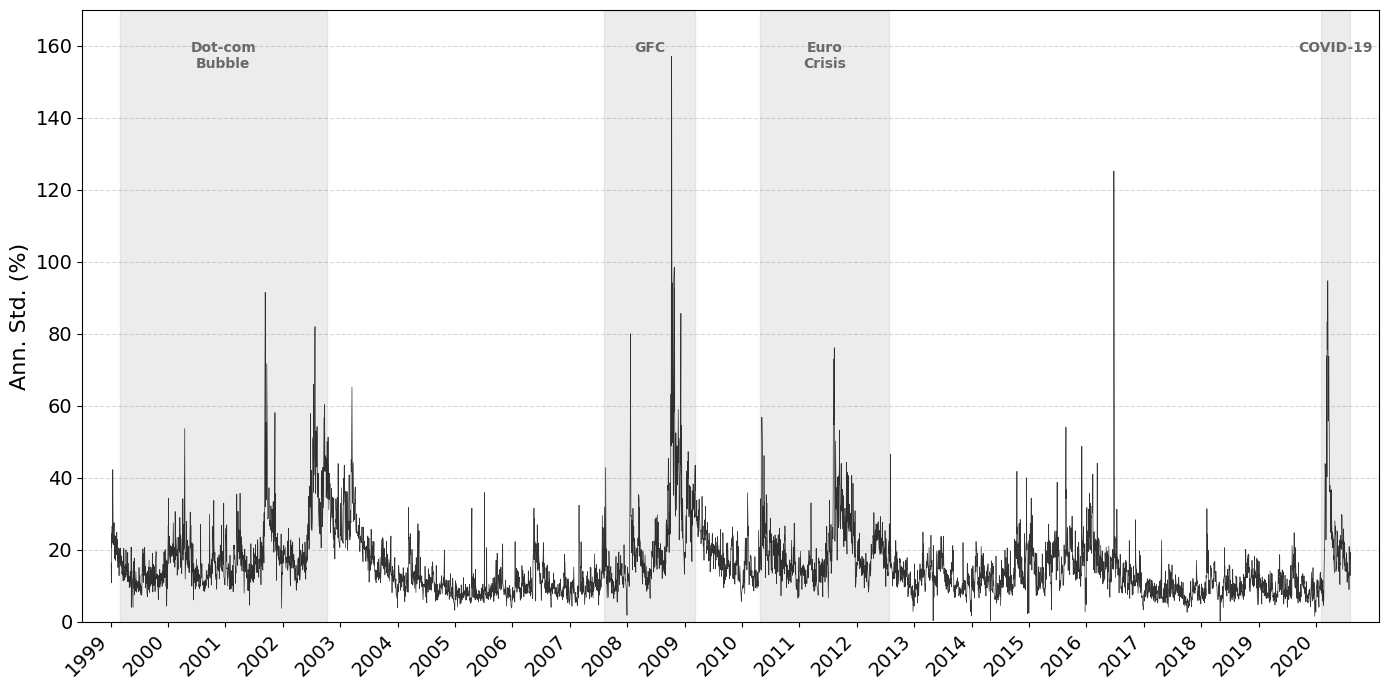

In [44]:

# Optional figure export directory for the 5-minute project
figure_dir = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Data"
os.makedirs(figure_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 7))
rv_ann = np.sqrt(MALL["RVD"] * 252) * 100

ax.plot(MALL.index, rv_ann, color="black", linewidth=0.5, alpha=0.8)
ax.set_ylabel("Ann. Std. (%)", fontsize=16)
ax.set_ylim(0, 170)

start_data = MALL.index.min()
end_data = MALL.index.max()
padding = pd.DateOffset(months=6)
ax.set_xlim(start_data - padding, end_data + padding)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

valid_ticks = [
    t for t in ax.get_xticks()
    if mdates.date2num(pd.Timestamp(f"{start_data.year}-01-01")) <= t
    <= mdates.date2num(pd.Timestamp(f"{end_data.year}-12-31"))
]
ax.set_xticks(valid_ticks)
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)

crisis_periods = [
    ("1999-03-01", "2002-10-09", "Dot-com\nBubble"),
    ("2007-08-09", "2009-03-09", "GFC"),
    ("2010-04-27", "2012-07-26", "Euro\nCrisis"),
    ("2020-02-01", "2020-08-07", "COVID-19"),
]

for start, end, label in crisis_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color="gray")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.95, label, fontsize=10, ha="center", va="top", color="dimgray", fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "RV_time_series_5min.pdf"), format="pdf", bbox_inches="tight")
plt.show()


#### Box Plot

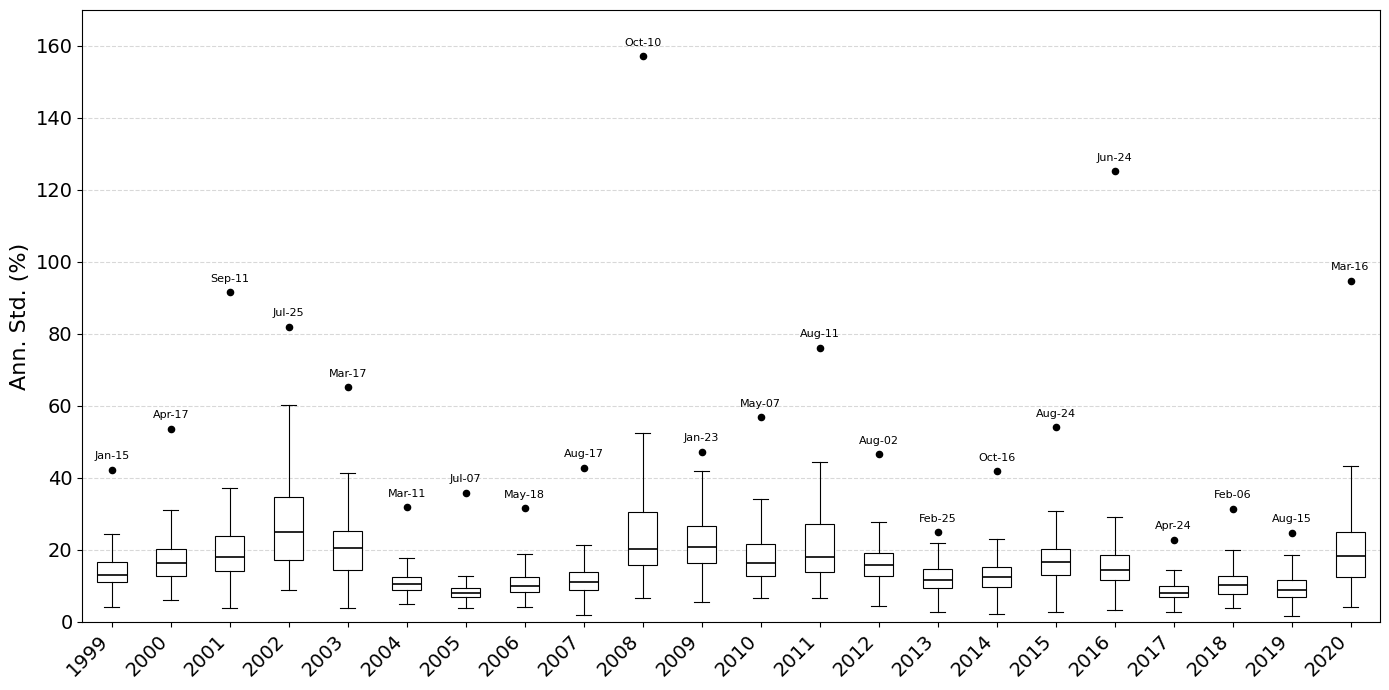

In [47]:

rv_ann = np.sqrt(MALL["RVD"] * 252) * 100
rv_ann_df = pd.DataFrame({
    "RVD_ann": rv_ann,
    "Year": MALL.index.year,
    "Date": MALL.index,
})

years = sorted(rv_ann_df["Year"].unique())
data_by_year = [rv_ann_df[rv_ann_df["Year"] == y]["RVD_ann"].values for y in years]

yearly_max_idx = rv_ann_df.groupby("Year")["RVD_ann"].idxmax()
yearly_max_val = rv_ann_df.loc[yearly_max_idx, "RVD_ann"]
yearly_max_date = rv_ann_df.loc[yearly_max_idx, "Date"]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(
    data_by_year,
    positions=range(len(years)),
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="white", color="black", linewidth=0.8),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)

y_range = rv_ann_df["RVD_ann"].max() - rv_ann_df["RVD_ann"].min()
fixed_offset = y_range * 0.015

for i, year in enumerate(years):
    max_val = yearly_max_val[yearly_max_val.index == yearly_max_idx[year]].values[0]
    max_date = yearly_max_date[yearly_max_date.index == yearly_max_idx[year]].values[0]
    max_date_str = pd.Timestamp(max_date).strftime("%b-%d")
    ax.scatter(i, max_val, color="black", s=20, zorder=5, marker="o")
    ax.text(i, max_val + fixed_offset, max_date_str, fontsize=8, ha="center", va="bottom", color="black")

ax.set_ylim(0, 170)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, ha="right", fontsize=14)
ax.set_ylabel("Ann. Std. (%)", fontsize=16)
plt.yticks(fontsize=14)
ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "RV_box_plot_5min.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [49]:
MALL.columns

Index(['RVD', 'RVW', 'RVM', 'logRVD', 'logRVW', 'logRVM', 'RVD_pos', 'RVD_neg',
       'RD_neg', 'RW_neg', 'RM_neg', 'RQ', 'VSTOXX', 'logVSTOXX', 'EPU',
       'logEPU', 'EPU_1m_lag', 'logEPU_1m_lag', 'EURUSD', 'EURUSD_ret', 'CISS',
       'BRENT', 'BRENT_ret', 'NIKKEI_ret', 'NIKKEI_sq', 'SP500_ret_lag',
       'SP500_sq_lag', 'M1W', 'M1M', 'RV_target', 'logRV_target'],
      dtype='object')

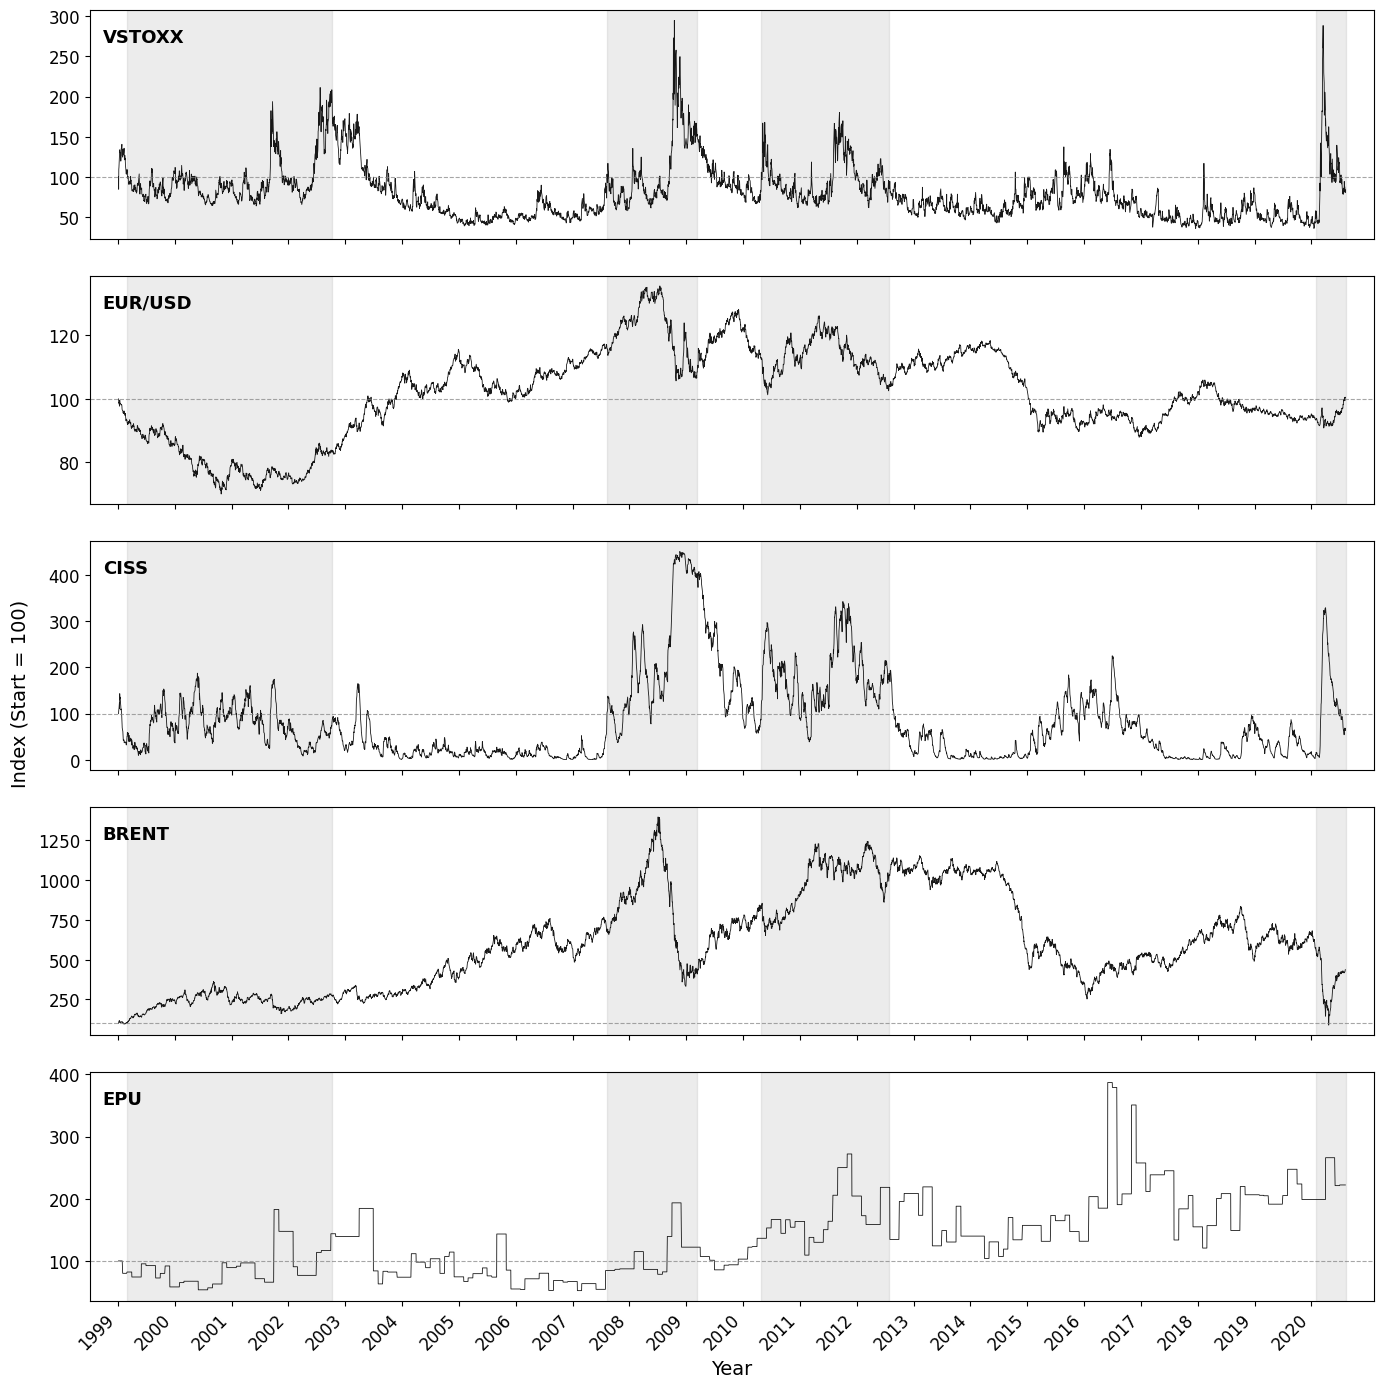

In [51]:

# Macro-financial panels indexed to 100 at the start of the sample
cols = ["VSTOXX", "EURUSD", "CISS", "BRENT", "EPU"]

df_plot = MALL[cols].copy()
df_plot.index = pd.to_datetime(df_plot.index)
df_plot = df_plot.sort_index().dropna()
df_indexed = df_plot.div(df_plot.iloc[0]).mul(100)

crisis_periods = [
    ("1999-03-01", "2002-10-09"),
    ("2007-08-09", "2009-03-09"),
    ("2010-04-27", "2012-07-26"),
    ("2020-02-01", "2020-08-07"),
]

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
series_names = ["VSTOXX", "EURUSD", "CISS", "BRENT", "EPU"]
panel_labels = ["VSTOXX", "EUR/USD", "CISS", "BRENT", "EPU"]

start_data = df_indexed.index.min()
end_data = df_indexed.index.max()
padding = pd.DateOffset(months=6)

for ax, col, label in zip(axes, series_names, panel_labels):
    ax.plot(df_indexed.index, df_indexed[col], color="black", linewidth=0.6, alpha=0.9)
    ax.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    for start, end in crisis_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="gray", alpha=0.15)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    ax.grid(False)
    ax.text(0.01, 0.92, label, transform=ax.transAxes, fontsize=13, fontweight="bold", ha="left", va="top")
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=12)
    ax.set_xlim(start_data - padding, end_data + padding)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
valid_ticks = [
    t for t in axes[-1].get_xticks()
    if mdates.date2num(pd.Timestamp(f"{start_data.year}-01-01")) <= t
    <= mdates.date2num(pd.Timestamp(f"{end_data.year}-12-31"))
]
axes[-1].set_xticks(valid_ticks)
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right", fontsize=12)

for ax in axes[:-1]:
    ax.tick_params(axis="x", labelbottom=False)

fig.supylabel("Index (Start = 100)", fontsize=14, x=0.015)
axes[-1].set_xlabel("Year", fontsize=14)

plt.tight_layout()
fig.subplots_adjust(hspace=0.16)
plt.savefig(os.path.join(figure_dir, "macro_panels_with_EPU_5min.pdf"), format="pdf", bbox_inches="tight")
plt.show()


## 2.0 Save MALL_5min.csv

In [54]:

# Save the completed 5-minute MALL dataset
folder_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets"
os.makedirs(folder_path, exist_ok=True)
file_path = os.path.join(folder_path, "MALL_5min.csv")
MALL.to_csv(file_path, index=True)
print(f"\nFile saved successfully at: {file_path}")



File saved successfully at: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv
